<a href="https://colab.research.google.com/github/carloselizondo05/Responsible-Credit-Scoring-Predictive-Risk-Modeling/blob/main/CIND_820_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Set your Kaggle API token for kagglehub authentication
os.environ["KAGGLE_API_TOKEN"] = "KGAT_730ae8d7982c97f35d20f047cc217e10"

In [ ]:
import os
import sqlite3
import pandas as pd
import numpy as np

# Install the updated Kaggle utility if not present
!pip install kagglehub -q
import kagglehub

# Download the specific dataset requested in your proposal
path = kagglehub.competition_download("home-credit-default-risk")
print("Dataset downloaded to:", path)

100%|██████████| 688M/688M [00:04<00:00, 148MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/competitions/home-credit-default-risk


In [ ]:
# Initialize or connect to SQLite database
db_path = "home_credit_data.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

def csv_to_sqlite(csv_name, table_name, chunksize=100000):
    """Streams large CSV files into SQLite to respect Colab RAM limits."""
    csv_file_path = os.path.join(path, csv_name)
    print(f"Ingesting {csv_name} into SQL table '{table_name}'...")

    # Process file in manageable bites
    for i, chunk in enumerate(pd.read_csv(csv_file_path, chunksize=chunksize)):
        # Memory optimization: Downcast numerical columns safely during ingest
        for col in chunk.select_dtypes(include=['float64']).columns:
            chunk[col] = chunk[col].astype('float32')
        for col in chunk.select_dtypes(include=['int64']).columns:
            chunk[col] = chunk[col].astype('int32')

        # Write to SQL (Creates table on first loop, appends thereafter)
        if i == 0:
            chunk.to_sql(table_name, conn, if_exists='replace', index=False)
        else:
            chunk.to_sql(table_name, conn, if_exists='append', index=False)

    print(f" Successfully loaded '{table_name}'.")

# Core tables needed for Stage 1 & Stage 2
csv_to_sqlite("application_train.csv", "application_train")
csv_to_sqlite("installments_payments.csv", "installments_payments")
csv_to_sqlite("bureau.csv", "bureau")

Ingesting application_train.csv into SQL table 'application_train'...
 Successfully loaded 'application_train'.
Ingesting installments_payments.csv into SQL table 'installments_payments'...
 Successfully loaded 'installments_payments'.
Ingesting bureau.csv into SQL table 'bureau'...
 Successfully loaded 'bureau'.


In [ ]:
import sqlite3

# 1. Re-open the database connection
db_path = "home_credit_data.db"
conn = sqlite3.connect(db_path)

# 2. Now run the ingestion block—it will work perfectly now!
csv_to_sqlite("bureau_balance.csv", "bureau_balance")

# 3. Always remember to close it when this specific cell is done
conn.close()

Ingesting bureau_balance.csv into SQL table 'bureau_balance'...
 Successfully loaded 'bureau_balance'.


In [ ]:
import sqlite3

# 1. Re-open the database connection to your local SQLite file
db_path = "home_credit_data.db"
conn = sqlite3.connect(db_path)

# 2. Stream and ingest the remaining 3 history files in manageable chunks
csv_to_sqlite("previous_application.csv", "previous_application")
csv_to_sqlite("POS_CASH_balance.csv", "POS_CASH_balance")
csv_to_sqlite("credit_card_balance.csv", "credit_card_balance")

# 3. Cleanly close the database connection when processing completes
conn.close()
print("\n All 7 tables are now successfully loaded into your SQLite database!")

Ingesting previous_application.csv into SQL table 'previous_application'...
 Successfully loaded 'previous_application'.
Ingesting POS_CASH_balance.csv into SQL table 'POS_CASH_balance'...
 Successfully loaded 'POS_CASH_balance'.
Ingesting credit_card_balance.csv into SQL table 'credit_card_balance'...
 Successfully loaded 'credit_card_balance'.

 All 7 tables are now successfully loaded into your SQLite database!


In [ ]:
# Updated SQL Query aggregating BOTH Payment Histories AND External Bureau Credit Profiles
aggregation_query = """
SELECT
    a.SK_ID_CURR,
    a.TARGET,
    a.CODE_GENDER,         -- Retained for Fairness auditing splits
    a.DAYS_BIRTH,          -- Retained for Fairness auditing splits

    -- Feature Engineering: Handle the 365243 anomaly directly at extraction
    CASE WHEN a.DAYS_EMPLOYED = 365243 THEN NULL ELSE a.DAYS_EMPLOYED END AS DAYS_EMPLOYED_CLEAN,
    a.AMT_INCOME_TOTAL,
    a.AMT_CREDIT,
    a.AMT_ANNUITY,

    -- Composite Financial Stress Ratios (Stage 2)
    (a.AMT_CREDIT / NULLIF(a.AMT_INCOME_TOTAL, 0)) AS DEBT_TO_INCOME_RATIO,
    (a.AMT_ANNUITY / NULLIF(a.AMT_INCOME_TOTAL, 0)) AS ANNUITY_TO_INCOME_RATIO,

    -- Behavioral Aggregates (Installments Payments)
    COUNT(DISTINCT i.SK_ID_PREV) AS TOTAL_HISTORICAL_INSTALLMENTS,
    AVG(i.DAYS_ENTRY_PAYMENT - i.DAYS_INSTALMENT) AS AVG_PAYMENT_DELAY_DAYS,
    MAX(i.DAYS_ENTRY_PAYMENT - i.DAYS_INSTALMENT) AS MAX_DAYS_PAST_DUE,
    SUM(CASE WHEN i.DAYS_ENTRY_PAYMENT > i.DAYS_INSTALMENT THEN 1 ELSE 0 END) AS COUNT_OF_LATE_PAYMENTS,

    -- External Bureau Aggregates (Stage 2 Features Added Here!)
    COUNT(DISTINCT b.SK_ID_BUREAU) AS TOTAL_BUREAU_LOANS,
    SUM(CASE WHEN b.CREDIT_ACTIVE = 'Active' THEN 1 ELSE 0 END) AS ACTIVE_LOANS_COUNT,
    SUM(b.AMT_CREDIT_SUM_DEBT) AS TOTAL_BUREAU_DEBT

FROM application_train a
LEFT JOIN installments_payments i
    ON a.SK_ID_CURR = i.SK_ID_CURR
    AND i.DAYS_INSTALMENT < 0
LEFT JOIN bureau b
    ON a.SK_ID_CURR = b.SK_ID_CURR
GROUP BY a.SK_ID_CURR;
"""

print("Executing Stage 2 SQL pipeline relational aggregation...")
db_path = "home_credit_data.db"
conn = sqlite3.connect(db_path)
df_engineered = pd.read_sql_query(aggregation_query, conn)

# Explicitly handling the missing values created by our 365243 cleaning logic
df_engineered['DAYS_EMPLOYED_CLEAN'] = df_engineered['DAYS_EMPLOYED_CLEAN'].fillna(0)
conn.close()

print(f"Aggregated Model Matrix Shape: {df_engineered.shape}")
print(df_engineered[['DEBT_TO_INCOME_RATIO', 'TOTAL_BUREAU_LOANS', 'TOTAL_BUREAU_DEBT']].head())

Executing Stage 2 SQL pipeline relational aggregation...
Aggregated Model Matrix Shape: (307511, 17)
   DEBT_TO_INCOME_RATIO  TOTAL_BUREAU_LOANS  TOTAL_BUREAU_DEBT
0              2.007889                   8          4669839.0
1              4.790750                   4                0.0
2              2.000000                   2                0.0
3              2.316167                   0                NaN
4              4.222222                   1                0.0


In [ ]:
# PREVIOUS COMMANDS
import sys
!pip install ydata-profiling
!jupyter nbextension enable --py widgetsnbextension
!pip install matplotlib
!pip install graphviz
# 1. CORE LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. MACHINE LEARNING
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 3. SQL INTEGRATION (Run '!pip install pandasql' in a separate cell if not installed)
!pip install pandasql
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.9 MB/s eta 0:00:00
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK
  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=a8bce2997a988de60d35b6b45ea75f8389e4328ce4dd4e8de2ae8e0868f59171
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Create a dedicated directory in your Google Drive if it doesn't exist
save_dir = '/content/drive/MyDrive/CIND820_Project'
os.makedirs(save_dir, exist_ok=True)

# Save your master matrix
df_engineered.to_csv(os.path.join(save_dir, 'clean_master_applicants.csv'), index=False)
print("✔ Your 307,511 applicant rows are safely saved to Google Drive!")

✔ Your 307,511 applicant rows are safely saved to Google Drive!


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Load your progress instantly
df_engineered = pd.read_csv('/content/drive/MyDrive/CIND820_Project/clean_master_applicants.csv')
print(f"Data successfully restored! Shape: {df_engineered.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data successfully restored! Shape: (307511, 14)


=== BASELINE AUDIT: RAW MISSING VALUES & OUTLIERS ===

--- Raw Missing Value Count & Percentage ---
                               Missing Rows  Percentage (%)
DAYS_EMPLOYED_CLEAN                       0            0.00
AMT_INCOME_TOTAL                          0            0.00
AMT_CREDIT                                0            0.00
AMT_ANNUITY                              12            0.00
DEBT_TO_INCOME_RATIO                      0            0.00
ANNUITY_TO_INCOME_RATIO                  12            0.00
TOTAL_HISTORICAL_INSTALLMENTS             0            0.00
AVG_PAYMENT_DELAY_DAYS                15876            5.16
MAX_DAYS_PAST_DUE                     15876            5.16
COUNT_OF_LATE_PAYMENTS                    0            0.00

💡 NOTE FOR YOUR REPORT: The high missing percentages in behavioral features
(like AVG_PAYMENT_DELAY_DAYS) represent your 'thin-file' applicants who have
never had a historical loan installment with this bank before.


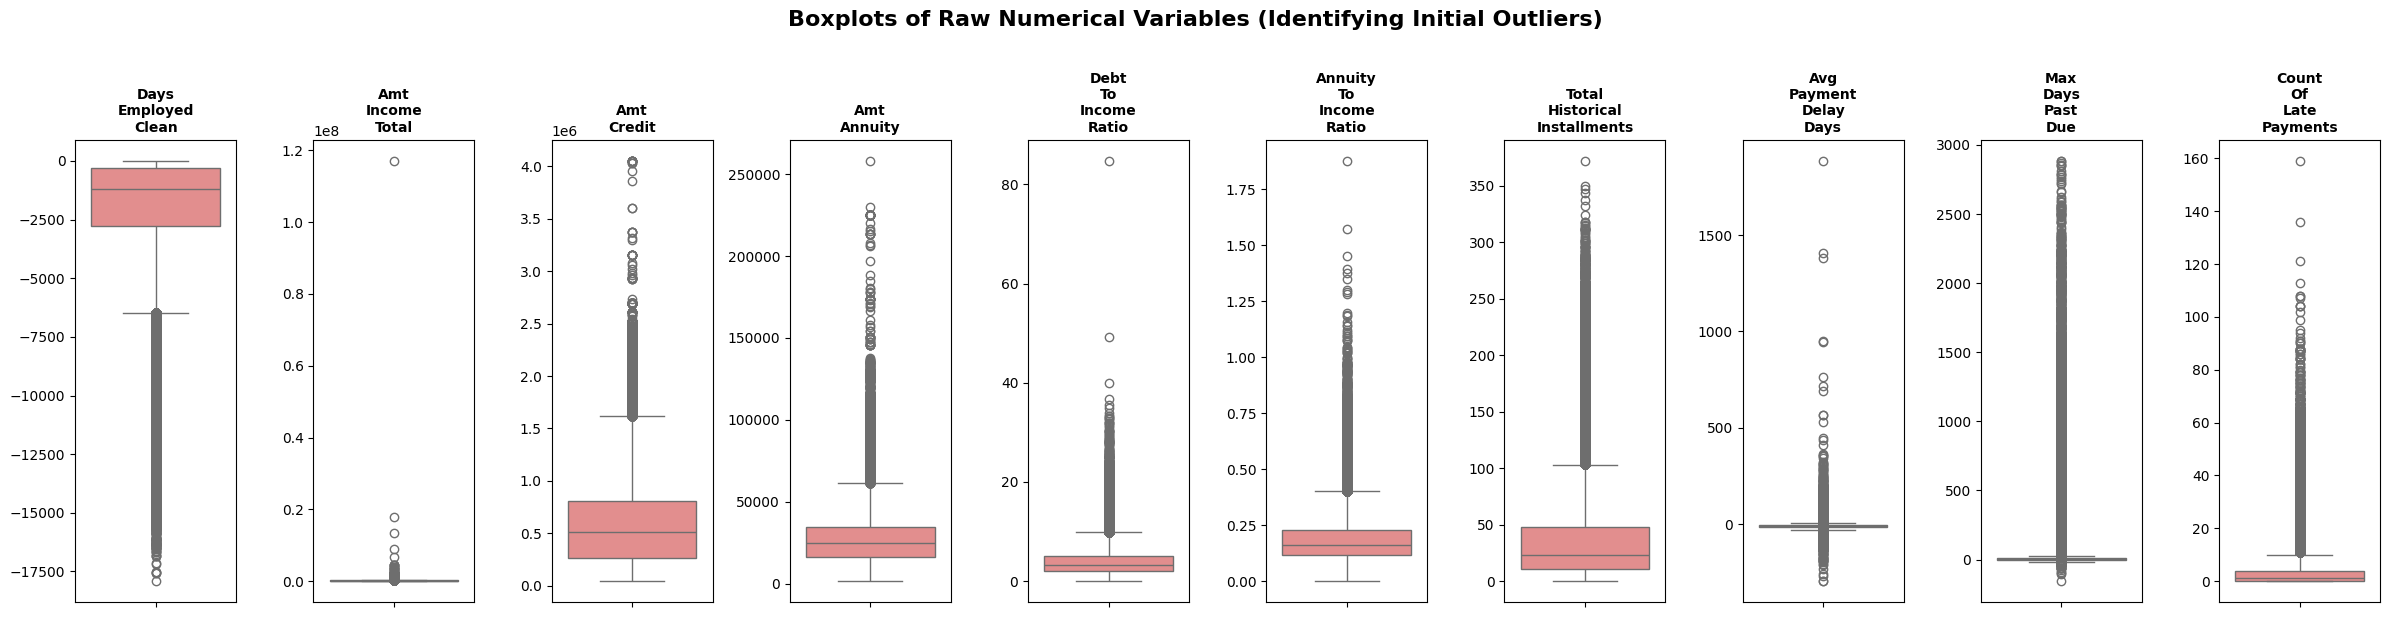

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("=== BASELINE AUDIT: RAW MISSING VALUES & OUTLIERS ===")

# 1. Isolate our raw, engineered feature set before any cleanup steps are applied
raw_features = [
    'DAYS_EMPLOYED_CLEAN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DEBT_TO_INCOME_RATIO', 'ANNUITY_TO_INCOME_RATIO', 'TOTAL_HISTORICAL_INSTALLMENTS',
    'AVG_PAYMENT_DELAY_DAYS', 'MAX_DAYS_PAST_DUE', 'COUNT_OF_LATE_PAYMENTS'
]

# 2. Generate the Raw Missing Value Report
print("\n--- Raw Missing Value Count & Percentage ---")
missing_counts = df_engineered[raw_features].isnull().sum()
missing_percentages = (df_engineered[raw_features].isnull().sum() / len(df_engineered)) * 100

missing_report = pd.DataFrame({
    'Missing Rows': missing_counts,
    'Percentage (%)': missing_percentages
}).round(2)
print(missing_report)

print("\n💡 NOTE FOR YOUR REPORT: The high missing percentages in behavioral features")
print("(like AVG_PAYMENT_DELAY_DAYS) represent your 'thin-file' applicants who have")
print("never had a historical loan installment with this bank before.")

# 3. Generate Raw Outlier Boxplots (Matching the layout of your previous project)
fig, axes = plt.subplots(1, len(raw_features), figsize=(24, 6))

for i, col in enumerate(raw_features):
    # Using a soft red to visually signify uncleaned/raw outlier states
    sns.boxplot(y=df_engineered[col], ax=axes[i], color='lightcoral')

    # Clean up column names for graph display titles
    display_title = col.replace('_', '\n').title()
    axes[i].set_title(display_title, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('')

plt.suptitle("Boxplots of Raw Numerical Variables (Identifying Initial Outliers)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


=== RENDERING COMPLETELY EXPANDED SCHEMA MATRICES ===


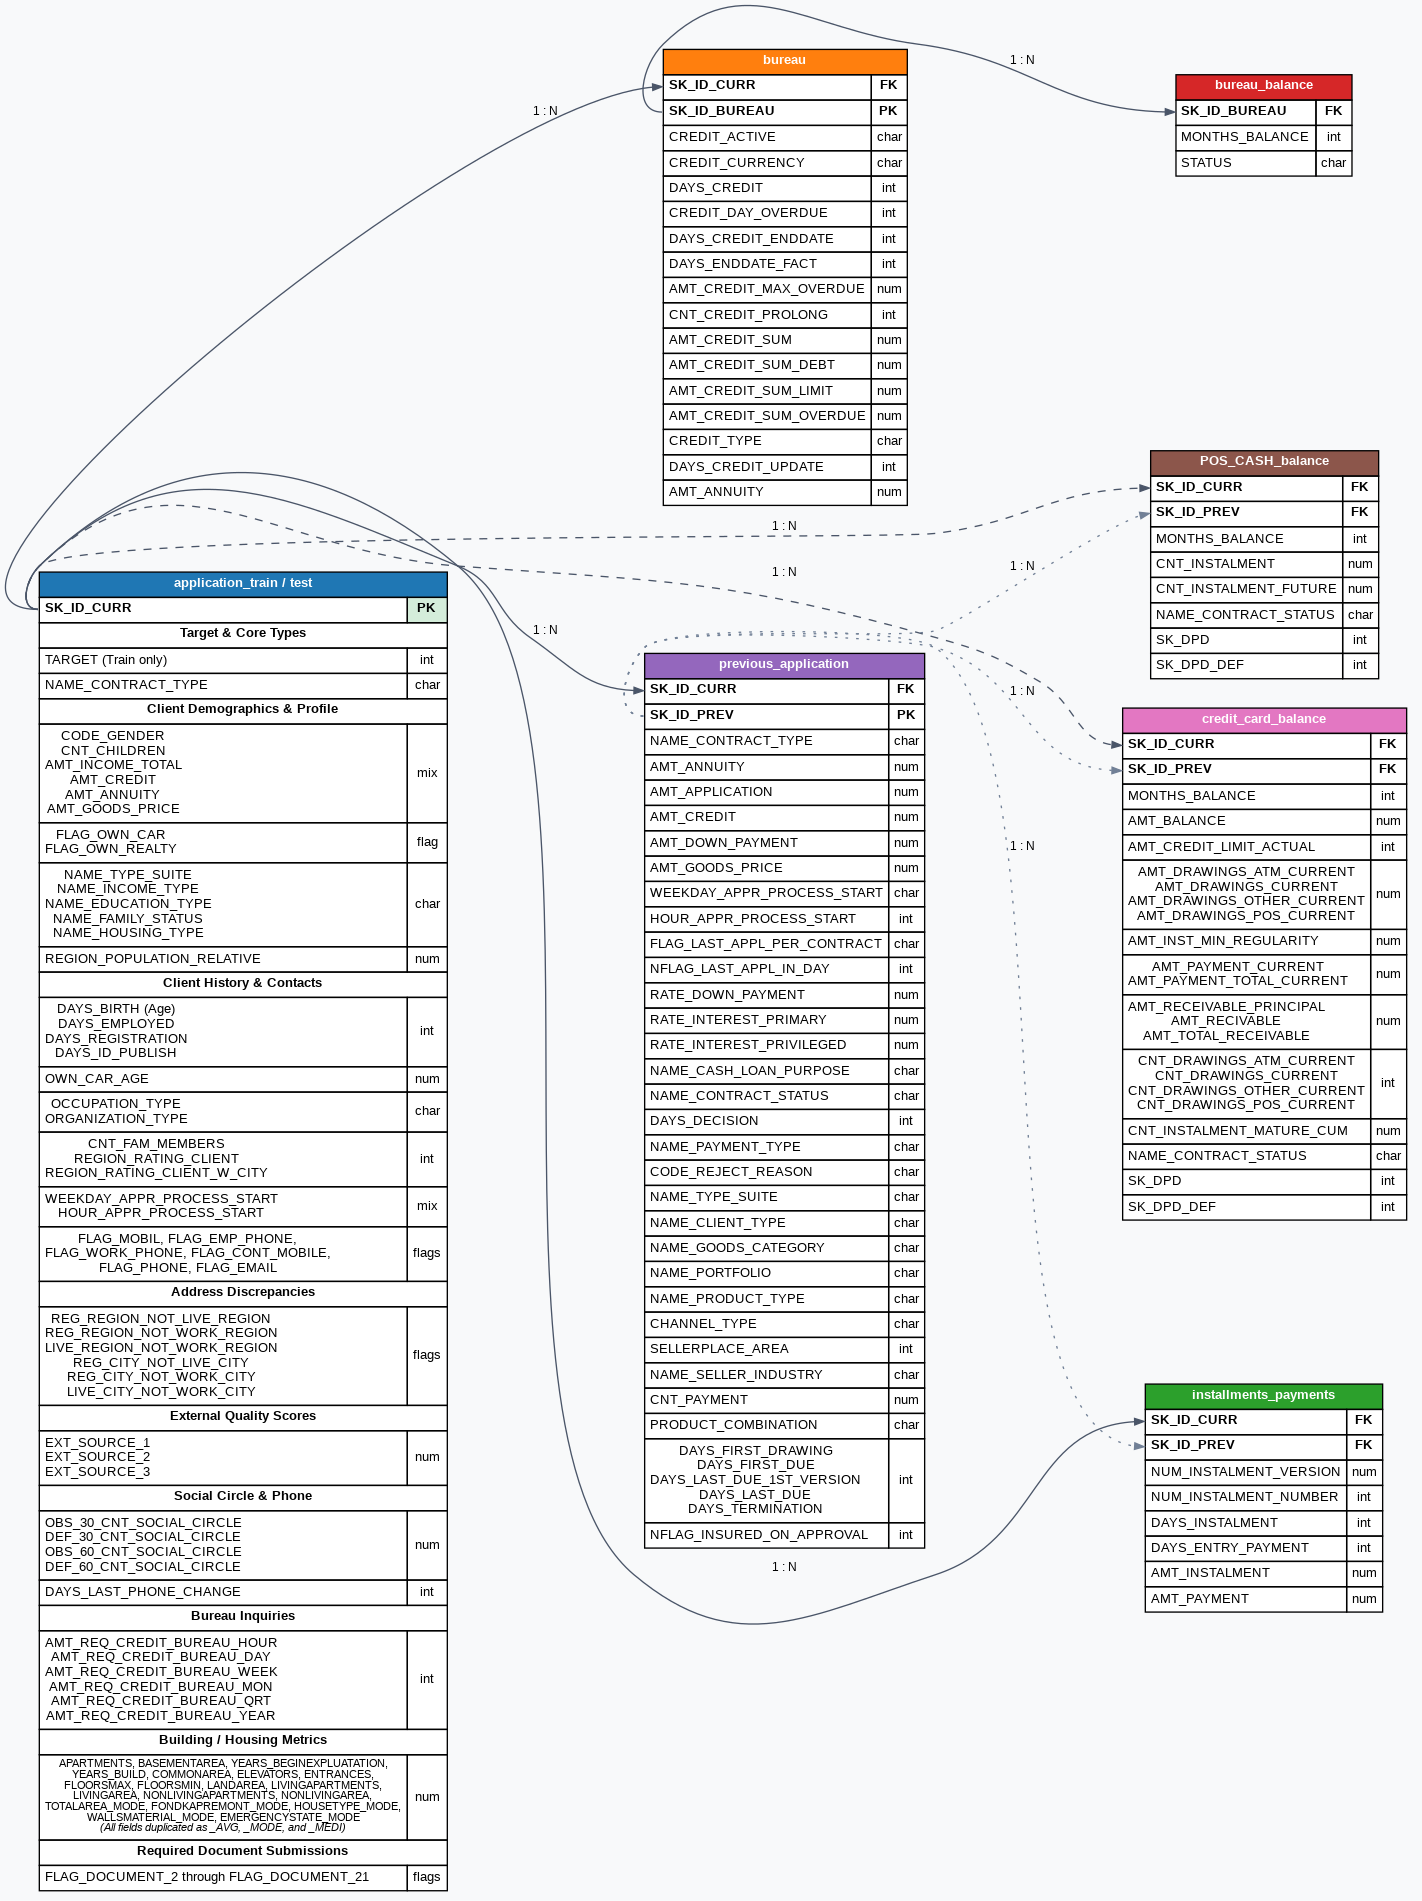

In [ ]:
import graphviz
from IPython.display import Image, display

# Initialize the fully expanded graphviz digraph
dot = graphviz.Digraph(
    comment='Home Credit Fully Expanded Data Schema',
    graph_attr={'rankdir':'LR', 'bgcolor':'#f8f9fa', 'splines':'true', 'nodesep':'0.2', 'ranksep':'1.5'},
    node_attr={'shape':'none', 'fontname':'Helvetica,Arial,sans-serif', 'fontsize':'10'},
    edge_attr={'fontname':'Helvetica,Arial,sans-serif', 'fontsize':'9', 'color':'#4A5568', 'arrowsize':'0.7'}
)

# ==========================================
# 1. APPLICATION MAIN TABLE (All 122 Column Keys/Groups)
# ==========================================
dot.node('app', '''<
<table border="0" cellborder="1" cellspacing="0" cellpadding="3" bgcolor="#ffffff">
  <tr><td bgcolor="#1f77b4" align="center" colspan="2"><font color="white"><b>application_train / test</b></font></td></tr>
  <tr bgcolor="#d4edda"><td port="pk" align="left"><b>SK_ID_CURR</b></td><td bgcolor="#d4edda"><b>PK</b></td></tr>
  <tr bgcolor="#e2e8f0"><td align="center" colspan="2"><b>Target &amp; Core Types</b></td></tr>
  <tr><td align="left">TARGET (Train only)</td><td>int</td></tr>
  <tr><td align="left">NAME_CONTRACT_TYPE</td><td>char</td></tr>
  <tr bgcolor="#e2e8f0"><td align="center" colspan="2"><b>Client Demographics &amp; Profile</b></td></tr>
  <tr><td align="left">CODE_GENDER<br/>CNT_CHILDREN<br/>AMT_INCOME_TOTAL<br/>AMT_CREDIT<br/>AMT_ANNUITY<br/>AMT_GOODS_PRICE</td><td>mix</td></tr>
  <tr><td align="left">FLAG_OWN_CAR<br/>FLAG_OWN_REALTY</td><td>flag</td></tr>
  <tr><td align="left">NAME_TYPE_SUITE<br/>NAME_INCOME_TYPE<br/>NAME_EDUCATION_TYPE<br/>NAME_FAMILY_STATUS<br/>NAME_HOUSING_TYPE</td><td>char</td></tr>
  <tr><td align="left">REGION_POPULATION_RELATIVE</td><td>num</td></tr>
  <tr bgcolor="#e2e8f0"><td align="center" colspan="2"><b>Client History &amp; Contacts</b></td></tr>
  <tr><td align="left">DAYS_BIRTH (Age)<br/>DAYS_EMPLOYED<br/>DAYS_REGISTRATION<br/>DAYS_ID_PUBLISH</td><td>int</td></tr>
  <tr><td align="left">OWN_CAR_AGE</td><td>num</td></tr>
  <tr><td align="left">OCCUPATION_TYPE<br/>ORGANIZATION_TYPE</td><td>char</td></tr>
  <tr><td align="left">CNT_FAM_MEMBERS<br/>REGION_RATING_CLIENT<br/>REGION_RATING_CLIENT_W_CITY</td><td>int</td></tr>
  <tr><td align="left">WEEKDAY_APPR_PROCESS_START<br/>HOUR_APPR_PROCESS_START</td><td>mix</td></tr>
  <tr><td align="left">FLAG_MOBIL, FLAG_EMP_PHONE,<br/>FLAG_WORK_PHONE, FLAG_CONT_MOBILE,<br/>FLAG_PHONE, FLAG_EMAIL</td><td>flags</td></tr>
  <tr bgcolor="#e2e8f0"><td align="center" colspan="2"><b>Address Discrepancies</b></td></tr>
  <tr><td align="left">REG_REGION_NOT_LIVE_REGION<br/>REG_REGION_NOT_WORK_REGION<br/>LIVE_REGION_NOT_WORK_REGION<br/>REG_CITY_NOT_LIVE_CITY<br/>REG_CITY_NOT_WORK_CITY<br/>LIVE_CITY_NOT_WORK_CITY</td><td>flags</td></tr>
  <tr bgcolor="#e2e8f0"><td align="center" colspan="2"><b>External Quality Scores</b></td></tr>
  <tr bgcolor="#fff3cd"><td align="left">EXT_SOURCE_1<br/>EXT_SOURCE_2<br/>EXT_SOURCE_3</td><td>num</td></tr>
  <tr bgcolor="#e2e8f0"><td align="center" colspan="2"><b>Social Circle &amp; Phone</b></td></tr>
  <tr><td align="left">OBS_30_CNT_SOCIAL_CIRCLE<br/>DEF_30_CNT_SOCIAL_CIRCLE<br/>OBS_60_CNT_SOCIAL_CIRCLE<br/>DEF_60_CNT_SOCIAL_CIRCLE</td><td>num</td></tr>
  <tr><td align="left">DAYS_LAST_PHONE_CHANGE</td><td>int</td></tr>
  <tr bgcolor="#e2e8f0"><td align="center" colspan="2"><b>Bureau Inquiries</b></td></tr>
  <tr><td align="left">AMT_REQ_CREDIT_BUREAU_HOUR<br/>AMT_REQ_CREDIT_BUREAU_DAY<br/>AMT_REQ_CREDIT_BUREAU_WEEK<br/>AMT_REQ_CREDIT_BUREAU_MON<br/>AMT_REQ_CREDIT_BUREAU_QRT<br/>AMT_REQ_CREDIT_BUREAU_YEAR</td><td>int</td></tr>
  <tr bgcolor="#e2e8f0"><td align="center" colspan="2"><b>Building / Housing Metrics</b></td></tr>
  <tr><td align="left"><font point-size="8">APARTMENTS, BASEMENTAREA, YEARS_BEGINEXPLUATATION,<br/>YEARS_BUILD, COMMONAREA, ELEVATORS, ENTRANCES,<br/>FLOORSMAX, FLOORSMIN, LANDAREA, LIVINGAPARTMENTS,<br/>LIVINGAREA, NONLIVINGAPARTMENTS, NONLIVINGAREA,<br/>TOTALAREA_MODE, FONDKAPREMONT_MODE, HOUSETYPE_MODE,<br/>WALLSMATERIAL_MODE, EMERGENCYSTATE_MODE<br/><i>(All fields duplicated as _AVG, _MODE, and _MEDI)</i></font></td><td>num</td></tr>
  <tr bgcolor="#e2e8f0"><td align="center" colspan="2"><b>Required Document Submissions</b></td></tr>
  <tr><td align="left">FLAG_DOCUMENT_2 through FLAG_DOCUMENT_21</td><td>flags</td></tr>
</table>>''')

# ==========================================
# 2. BUREAU TABLE
# ==========================================
dot.node('bur', '''<
<table border="0" cellborder="1" cellspacing="0" cellpadding="3" bgcolor="#ffffff">
  <tr><td bgcolor="#ff7f0e" align="center" colspan="2"><font color="white"><b>bureau</b></font></td></tr>
  <tr bgcolor="#fff3cd"><td port="fk" align="left"><b>SK_ID_CURR</b></td><td><b>FK</b></td></tr>
  <tr bgcolor="#fff3cd"><td port="pk" align="left"><b>SK_ID_BUREAU</b></td><td><b>PK</b></td></tr>
  <tr><td align="left">CREDIT_ACTIVE</td><td>char</td></tr>
  <tr><td align="left">CREDIT_CURRENCY</td><td>char</td></tr>
  <tr><td align="left">DAYS_CREDIT</td><td>int</td></tr>
  <tr><td align="left">CREDIT_DAY_OVERDUE</td><td>int</td></tr>
  <tr><td align="left">DAYS_CREDIT_ENDDATE</td><td>int</td></tr>
  <tr><td align="left">DAYS_ENDDATE_FACT</td><td>int</td></tr>
  <tr><td align="left">AMT_CREDIT_MAX_OVERDUE</td><td>num</td></tr>
  <tr><td align="left">CNT_CREDIT_PROLONG</td><td>int</td></tr>
  <tr><td align="left">AMT_CREDIT_SUM</td><td>num</td></tr>
  <tr><td align="left">AMT_CREDIT_SUM_DEBT</td><td>num</td></tr>
  <tr><td align="left">AMT_CREDIT_SUM_LIMIT</td><td>num</td></tr>
  <tr><td align="left">AMT_CREDIT_SUM_OVERDUE</td><td>num</td></tr>
  <tr><td align="left">CREDIT_TYPE</td><td>char</td></tr>
  <tr><td align="left">DAYS_CREDIT_UPDATE</td><td>int</td></tr>
  <tr><td align="left">AMT_ANNUITY</td><td>num</td></tr>
</table>>''')

# ==========================================
# 3. BUREAU BALANCE TABLE
# ==========================================
dot.node('bur_bal', '''<
<table border="0" cellborder="1" cellspacing="0" cellpadding="3" bgcolor="#ffffff">
  <tr><td bgcolor="#d62728" align="center" colspan="2"><font color="white"><b>bureau_balance</b></font></td></tr>
  <tr bgcolor="#fff3cd"><td port="fk" align="left"><b>SK_ID_BUREAU</b></td><td><b>FK</b></td></tr>
  <tr><td align="left">MONTHS_BALANCE</td><td>int</td></tr>
  <tr><td align="left">STATUS</td><td>char</td></tr>
</table>>''')

# ==========================================
# 4. PREVIOUS APPLICATION TABLE
# ==========================================
dot.node('prev_app', '''<
<table border="0" cellborder="1" cellspacing="0" cellpadding="3" bgcolor="#ffffff">
  <tr><td bgcolor="#9467bd" align="center" colspan="2"><font color="white"><b>previous_application</b></font></td></tr>
  <tr bgcolor="#fff3cd"><td port="fk" align="left"><b>SK_ID_CURR</b></td><td><b>FK</b></td></tr>
  <tr bgcolor="#fff3cd"><td port="pk" align="left"><b>SK_ID_PREV</b></td><td><b>PK</b></td></tr>
  <tr><td align="left">NAME_CONTRACT_TYPE</td><td>char</td></tr>
  <tr><td align="left">AMT_ANNUITY</td><td>num</td></tr>
  <tr><td align="left">AMT_APPLICATION</td><td>num</td></tr>
  <tr><td align="left">AMT_CREDIT</td><td>num</td></tr>
  <tr><td align="left">AMT_DOWN_PAYMENT</td><td>num</td></tr>
  <tr><td align="left">AMT_GOODS_PRICE</td><td>num</td></tr>
  <tr><td align="left">WEEKDAY_APPR_PROCESS_START</td><td>char</td></tr>
  <tr><td align="left">HOUR_APPR_PROCESS_START</td><td>int</td></tr>
  <tr><td align="left">FLAG_LAST_APPL_PER_CONTRACT</td><td>char</td></tr>
  <tr><td align="left">NFLAG_LAST_APPL_IN_DAY</td><td>int</td></tr>
  <tr><td align="left">RATE_DOWN_PAYMENT</td><td>num</td></tr>
  <tr><td align="left">RATE_INTEREST_PRIMARY</td><td>num</td></tr>
  <tr><td align="left">RATE_INTEREST_PRIVILEGED</td><td>num</td></tr>
  <tr><td align="left">NAME_CASH_LOAN_PURPOSE</td><td>char</td></tr>
  <tr><td align="left">NAME_CONTRACT_STATUS</td><td>char</td></tr>
  <tr><td align="left">DAYS_DECISION</td><td>int</td></tr>
  <tr><td align="left">NAME_PAYMENT_TYPE</td><td>char</td></tr>
  <tr><td align="left">CODE_REJECT_REASON</td><td>char</td></tr>
  <tr><td align="left">NAME_TYPE_SUITE</td><td>char</td></tr>
  <tr><td align="left">NAME_CLIENT_TYPE</td><td>char</td></tr>
  <tr><td align="left">NAME_GOODS_CATEGORY</td><td>char</td></tr>
  <tr><td align="left">NAME_PORTFOLIO</td><td>char</td></tr>
  <tr><td align="left">NAME_PRODUCT_TYPE</td><td>char</td></tr>
  <tr><td align="left">CHANNEL_TYPE</td><td>char</td></tr>
  <tr><td align="left">SELLERPLACE_AREA</td><td>int</td></tr>
  <tr><td align="left">NAME_SELLER_INDUSTRY</td><td>char</td></tr>
  <tr><td align="left">CNT_PAYMENT</td><td>num</td></tr>
  <tr><td align="left">PRODUCT_COMBINATION</td><td>char</td></tr>
  <tr><td align="left">DAYS_FIRST_DRAWING<br/>DAYS_FIRST_DUE<br/>DAYS_LAST_DUE_1ST_VERSION<br/>DAYS_LAST_DUE<br/>DAYS_TERMINATION</td><td>int</td></tr>
  <tr><td align="left">NFLAG_INSURED_ON_APPROVAL</td><td>int</td></tr>
</table>>''')

# ==========================================
# 5. POS CASH BALANCE TABLE
# ==========================================
dot.node('pos_bal', '''<
<table border="0" cellborder="1" cellspacing="0" cellpadding="3" bgcolor="#ffffff">
  <tr><td bgcolor="#8c564b" align="center" colspan="2"><font color="white"><b>POS_CASH_balance</b></font></td></tr>
  <tr bgcolor="#fff3cd"><td port="fk" align="left"><b>SK_ID_CURR</b></td><td><b>FK</b></td></tr>
  <tr bgcolor="#fff3cd"><td port="fk_prev" align="left"><b>SK_ID_PREV</b></td><td><b>FK</b></td></tr>
  <tr><td align="left">MONTHS_BALANCE</td><td>int</td></tr>
  <tr><td align="left">CNT_INSTALMENT</td><td>num</td></tr>
  <tr><td align="left">CNT_INSTALMENT_FUTURE</td><td>num</td></tr>
  <tr><td align="left">NAME_CONTRACT_STATUS</td><td>char</td></tr>
  <tr><td align="left">SK_DPD</td><td>int</td></tr>
  <tr><td align="left">SK_DPD_DEF</td><td>int</td></tr>
</table>>''')

# ==========================================
# 6. CREDIT CARD BALANCE TABLE
# ==========================================
dot.node('cc_bal', '''<
<table border="0" cellborder="1" cellspacing="0" cellpadding="3" bgcolor="#ffffff">
  <tr><td bgcolor="#e377c2" align="center" colspan="2"><font color="white"><b>credit_card_balance</b></font></td></tr>
  <tr bgcolor="#fff3cd"><td port="fk" align="left"><b>SK_ID_CURR</b></td><td><b>FK</b></td></tr>
  <tr bgcolor="#fff3cd"><td port="fk_prev" align="left"><b>SK_ID_PREV</b></td><td><b>FK</b></td></tr>
  <tr><td align="left">MONTHS_BALANCE</td><td>int</td></tr>
  <tr><td align="left">AMT_BALANCE</td><td>num</td></tr>
  <tr><td align="left">AMT_CREDIT_LIMIT_ACTUAL</td><td>int</td></tr>
  <tr><td align="left">AMT_DRAWINGS_ATM_CURRENT<br/>AMT_DRAWINGS_CURRENT<br/>AMT_DRAWINGS_OTHER_CURRENT<br/>AMT_DRAWINGS_POS_CURRENT</td><td>num</td></tr>
  <tr><td align="left">AMT_INST_MIN_REGULARITY</td><td>num</td></tr>
  <tr><td align="left">AMT_PAYMENT_CURRENT<br/>AMT_PAYMENT_TOTAL_CURRENT</td><td>num</td></tr>
  <tr><td align="left">AMT_RECEIVABLE_PRINCIPAL<br/>AMT_RECIVABLE<br/>AMT_TOTAL_RECEIVABLE</td><td>num</td></tr>
  <tr><td align="left">CNT_DRAWINGS_ATM_CURRENT<br/>CNT_DRAWINGS_CURRENT<br/>CNT_DRAWINGS_OTHER_CURRENT<br/>CNT_DRAWINGS_POS_CURRENT</td><td>int</td></tr>
  <tr><td align="left">CNT_INSTALMENT_MATURE_CUM</td><td>num</td></tr>
  <tr><td align="left">NAME_CONTRACT_STATUS</td><td>char</td></tr>
  <tr><td align="left">SK_DPD</td><td>int</td></tr>
  <tr><td align="left">SK_DPD_DEF</td><td>int</td></tr>
</table>>''')

# ==========================================
# 7. INSTALLMENTS PAYMENTS TABLE
# ==========================================
dot.node('inst', '''<
<table border="0" cellborder="1" cellspacing="0" cellpadding="3" bgcolor="#ffffff">
  <tr><td bgcolor="#2ca02c" align="center" colspan="2"><font color="white"><b>installments_payments</b></font></td></tr>
  <tr bgcolor="#fff3cd"><td port="fk" align="left"><b>SK_ID_CURR</b></td><td><b>FK</b></td></tr>
  <tr bgcolor="#fff3cd"><td port="fk_prev" align="left"><b>SK_ID_PREV</b></td><td><b>FK</b></td></tr>
  <tr><td align="left">NUM_INSTALMENT_VERSION</td><td>num</td></tr>
  <tr><td align="left">NUM_INSTALMENT_NUMBER</td><td>int</td></tr>
  <tr><td align="left">DAYS_INSTALMENT</td><td>int</td></tr>
  <tr><td align="left">DAYS_ENTRY_PAYMENT</td><td>int</td></tr>
  <tr><td align="left">AMT_INSTALMENT</td><td>num</td></tr>
  <tr><td align="left">AMT_PAYMENT</td><td>num</td></tr>
</table>>''')

# Establish correct point-to-point relational mappings using ports
dot.edge('app:pk', 'inst:fk', label=' 1 : N ')
dot.edge('app:pk', 'bur:fk', label=' 1 : N ')
dot.edge('bur:pk', 'bur_bal:fk', label=' 1 : N ')
dot.edge('app:pk', 'prev_app:fk', label=' 1 : N ')

# Alternative routes tracking history logs directly back to application keys
dot.edge('app:pk', 'pos_bal:fk', label=' 1 : N ', style='dashed')
dot.edge('app:pk', 'cc_bal:fk', label=' 1 : N ', style='dashed')

# Also show how history files connect back to the matching previous application records
dot.edge('prev_app:pk', 'inst:fk_prev', label=' 1 : N ', style='dotted', color='#718096')
dot.edge('prev_app:pk', 'pos_bal:fk_prev', label=' 1 : N ', style='dotted', color='#718096')
dot.edge('prev_app:pk', 'cc_bal:fk_prev', label=' 1 : N ', style='dotted', color='#718096')

# Render the output image file cleanly
dot.render("expanded_schema_view", format="png", cleanup=True)
print("\n=== RENDERING COMPLETELY EXPANDED SCHEMA MATRICES ===")
display(Image("expanded_schema_view.png"))